#**Capstone project: Can ML Outperform Market-Neutral Trading in Structural Breaks?**

**Note:**

It's always a good practise to "restart the session", whenever changes are made to github repository


##**Step 1:** GitHub setup

1) Clone/Update the projects github repository

In [1]:
# Use for the first time to clone the github repo or when the repo is updated
%rm -rf /content/MarketNeutral_Trading/
%cd /content
!git clone https://github.com/WQU-Capstone-11205/MarketNeutral_Trading.git
%cd /content/MarketNeutral_Trading

/content
Cloning into 'MarketNeutral_Trading'...
remote: Enumerating objects: 722, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 722 (delta 95), reused 4 (delta 4), pack-reused 556 (from 1)
Receiving objects: 100% (722/722), 711.70 KiB | 6.98 MiB/s, done.
Resolving deltas: 100% (398/398), done.
/content/MarketNeutral_Trading


2) Add the project's github repository's path to the system path

In [2]:
import sys
sys.path.append('/content/MarketNeutral_Trading')

3) Install projects required packages

In [3]:
!pip install -r requirements.txt

In [4]:
import warnings
warnings.filterwarnings('ignore')

##**Step 2:** Data loading

Load data and bechmark_strategy data

In [5]:
from data_loading.fetch_data import fetch_from_yfinance

# Example pair: XLF and FAS (Financial sector ETFs, often cointegrated)
ticker1 = 'XLF'
ticker2 = 'FAS'# Note: FAS is a leveraged ETF, may require careful handling/interpretation
start_date = '2005-01-01' #'2015-01-01'
end_date = '2025-01-01' # '2025-01-01'
data = fetch_from_yfinance([ticker1, ticker2], start_date, end_date)

# Fetch a benchmark for alpha/beta calculation (e.g., SPY)
benchmark_data = fetch_from_yfinance(['SPY'], start_date, end_date)
benchmark_returns = benchmark_data.pct_change().dropna()

# Use an in-sample period for training the cointegration relationship
train_data = data.loc[:'2017-01-01']
test_data = data.loc['2017-01-02':]


[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed


##**Step 3:** Check Cointegration and Hedge ratio


In [9]:
from metrics.stats import check_cointegration_and_hedge_ratio

beta, spread = check_cointegration_and_hedge_ratio(train_data[ticker1], train_data[ticker2])

print(f"Beta: {round(beta, 4)}")


Pair is cointegrated with p-value 0.0014. Hedge ratio (beta): 2.3761
Beta: 2.3761


##**Step 4:** Backtest the strategy and calculate performance metrics on out of sample data

In [12]:
from backtest.traditional_test import backtest_strategy
from util.metrics import calculate_performance_metrics

if beta is not None:
    # Backtest on the out-of-sample data
    returns, cumulative_returns = backtest_strategy(test_data, beta)

    # Calculate and print performance metrics
    metrics = calculate_performance_metrics(returns, cumulative_returns, benchmark_returns=benchmark_returns)

    print("\nPerformance Metrics (Out-of-Sample):")
    for key, value in metrics.items():
        print(f"{key}: {value:.4f}")




Performance Metrics (Out-of-Sample):
Annual Returns: 0.0326
Annual Volatility: 0.2259
Sharpe Ratio: 0.1000
Sortino Ratio: 0.0249
Max Drawdown: -0.4358
Alpha: 0.0519
Beta: -0.1294


##**Step 5:** Plots for the traditional strategy:

## 5.1) **Cumulative plot**

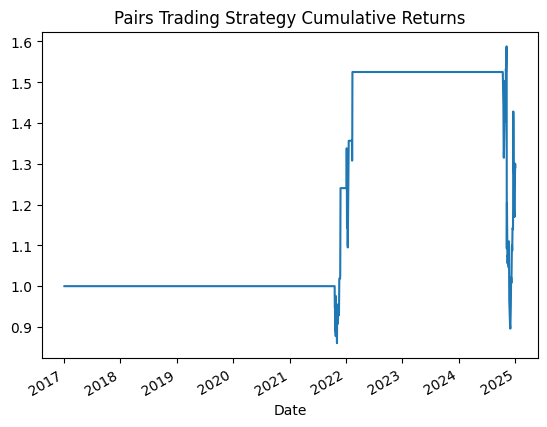

In [13]:
from matplotlib import pyplot as plt

# Plot cumulative returns
cumulative_returns.plot(title="Pairs Trading Strategy Cumulative Returns")
plt.show()

## 5.2) **Drawdown for PnL and Buy & Hold:**

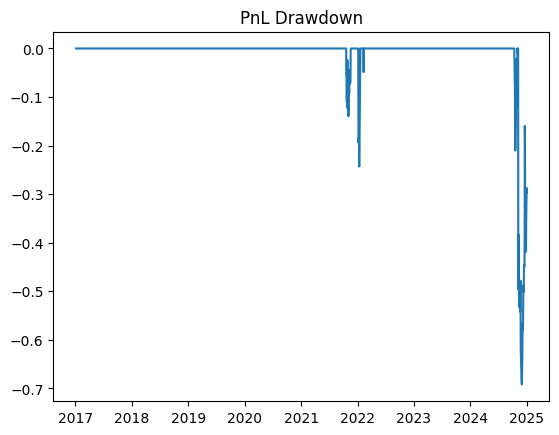

In [24]:
import numpy as np

sz = len(cumulative_returns)
cum_pnl_z = cumulative_returns
rolling_max_z = np.maximum.accumulate(cum_pnl_z)
drawdown_z = cum_pnl_z - rolling_max_z
plt.plot(cumulative_returns.index, drawdown_z, label="PnL")
plt.title("PnL Drawdown")
plt.show()
